Аббревиатура ***JSON*** расшифровывается как JavaScript Object Notation, в переводе на русский — система обозначения/записи объектов JavaScript. Несмотря на то, что JSON изначально основывался на языке программирования JavaScript, он является общепризнанным форматом обмена данными, и многие языки программирования, включая Python, содержат эффективные инструменты для работы с ним.

In [1]:
# Импортируем модуль json
import json

Также нам может быть полезен модуль ```pprint```  (от англ. pretty print, рус. красивый вывод на экран), а точнее — встроенная в него одноимённая функция pprint(), с помощью которой можно красиво выводить на экран содержимое JSON-файла. Для загрузки нужной нам функции перед началом работы выполним следующий код:

In [2]:
# Импортируем функцию pprint()
from pprint import pprint

Информация в формате JSON представляет собой (в закодированном виде) одну из двух структур:
* набор пар "ключ-значение", где ключ — это всегда строковая величина (в Python такая структура преобразуется в словарь);
* упорядоченный набор значений (при чтении JSON-файла в Python эта структура будет преобразована в список).

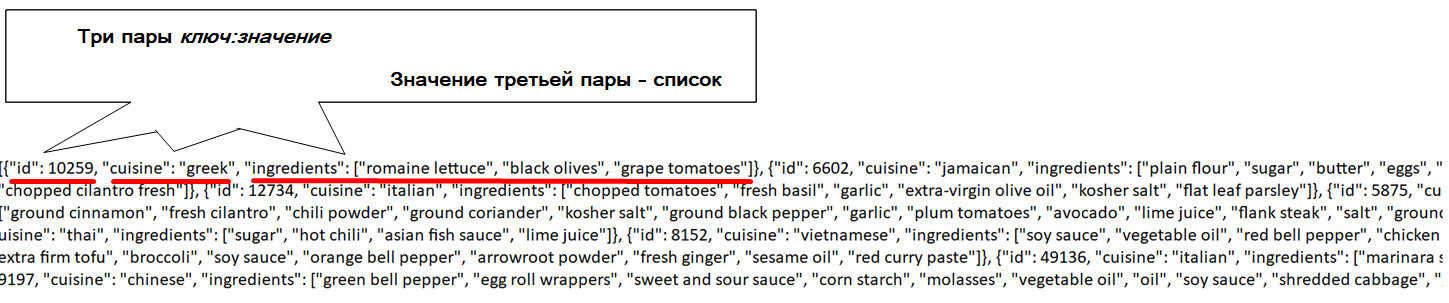

### ОТКРЫВАЕМ JSON-ФАЙЛ

Чтобы перевести данные из формата JSON в формат, который можно обрабатывать инструментами Python, необходимо выполнить процедуру, которая называется *десериализация* (декодирование данных). Обратный процесс, связанный с переводом структур данных Python в формат JSON, называется *сериализацией*.

Для выполнения десериализации мы воспользуемся методом ```load()``` (от англ. загрузить) модуля json, который принимает на вход ссылку на открытый JSON-файл:

In [3]:
# Открываем файл и связываем его с объектом "f"
with open('recipes.json') as f:  
    # Загружаем содержимое открытого файла в переменную recipes  
    recipes = json.load(f)

In [4]:
# Выводим на экран содержимое переменной recipes, используя функцию pprint()
pprint(recipes)

[{'cuisine': 'greek',
  'id': 10259,
  'ingredients': ['romaine lettuce',
                  'black olives',
                  'grape tomatoes',
                  'garlic',
                  'pepper',
                  'purple onion',
                  'seasoning',
                  'garbanzo beans',
                  'feta cheese crumbles']},
 {'cuisine': 'southern_us',
  'id': 25693,
  'ingredients': ['plain flour',
                  'ground pepper',
                  'salt',
                  'tomatoes',
                  'ground black pepper',
                  'thyme',
                  'eggs',
                  'green tomatoes',
                  'yellow corn meal',
                  'milk',
                  'vegetable oil']},
 {'cuisine': 'filipino',
  'id': 20130,
  'ingredients': ['eggs',
                  'pepper',
                  'salt',
                  'mayonaise',
                  'cooking oil',
                  'green chilies',
                  'grilled chicken bre

### ИЗВЛЕКАЕМ ДАННЫЕ ИЗ JSON-ФАЙЛА

In [5]:
recipes[0]['id']

10259

Здесь мы сначала извлекаем из списка первый элемент (индекс 0). Поскольку каждый элемент списка является словарём, для получения нужной информации о конкретном блюде нам нужно указать ключ словаря. ID блюда доступно по ключу 'id', и мы указываем этот ключ в отдельной паре квадратных скобок:

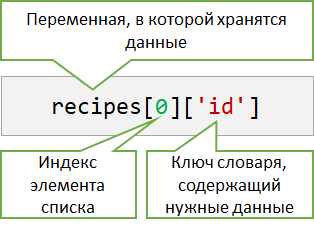

Аналогичным образом, для получения списка ингредиентов первого блюда в списке мы можем использовать тот же код, заменив в нём ключ 'id' на 'ingredients'. 

In [6]:
# Сколько ингредиентов входят в состав первого блюда из предлагаемого списка?

# Импортируем модуль json
import json 
# Импортируем функцию pprint()
from pprint import pprint 
# Открываем файл и связываем его с объектом "f"
with open('recipes.json') as f: 
    # Загружаем содержимое открытого файла в переменную recipes
    recipes = json.load(f) 
# Определяем количество ингредиентов в составе первого блюда/рецепта
len(recipes[0]['ingredients'])

9

Мы также можем извлечь информацию о конкретном блюде по его ID. Для этого необходимо с помощью цикла, например for, перебрать все элементы списка, проверяя ключ 'id',  и извлечь нужную информацию, когда мы наконец найдем нужное блюдо.

In [7]:
# К какой кухне относится блюдо с id = 13121

import json 
from pprint import pprint 

# Открываем файл и связываем его с объектом "f"
with open('recipes.json') as f: 
    # Загружаем содержимое открытого файла в переменную recipes
    recipes = json.load(f) 

# Начинаем перебор всех блюд, входящих в список
for recipe in recipes: 
    # Если id текущего блюда равен заданному для поиска
    if recipe['id'] == 13121: 
        # Выводим на экран наименование кухни, к которой относится блюдо
        print(recipe['cuisine']) 
        # Прерываем выполнение цикла, т.к. нужное блюдо найдено
        break

thai


* Задание 5.3 Какое количество уникальных национальных кухонь присутствуют в нашем наборе данных?

Вариант решения с использованием списка

Чтобы извлечь эту информацию, нам нужно создать пустой список и последовательно заполнять его уникальными значениями, доступными по ключу 'cuisine' в каждом из словарей, содержащих информацию о рецептах. Поскольку словари объединены в список recipes, не получится применить известный нам метод unique() (этот метод неприменим к словарям), и для извлечения всех уникальных значений нужно перебирать элементы списка в цикле с параметром.

Вариант решения с использованием множества

Другой способ решения этой же задачи — использование для хранения данных о разных кухнях не списка, а множества (set). Множество содержит только уникальные элементы, поэтому при работе с ним нет необходимости проверять, содержится ли там тот или иной элемент. Если элемент (в нашем примере — название типа кухни) уже есть, то команда "добавить во множество такое же значение" будет проигнорирована компьютером.

In [8]:
import json
from pprint import pprint
with open('recipes.json') as f:
    recipes = json.load(f)
lst = []
for recipe in recipes:
    if recipe['cuisine'] not in lst:
        lst.append(recipe['cuisine'])
print(len(lst))

20


In [9]:
import json
from pprint import pprint
with open('recipes.json') as f:
    recipes = json.load(f)
    
set_recipes = set()
for recipe in recipes:
    set_recipes.add(recipe['cuisine'])
    
print(len(set_recipes))

20


Задание 5.4
Какой из национальных кухонь принадлежит самое большое количество рецептов?

In [10]:
import json
from pprint import pprint
with open('recipes.json') as f:
    recipes = json.load(f)

recipes_dict = {}
for recipe in recipes:
    if recipe['cuisine'] not in recipes_dict.keys():
        recipes_dict[recipe['cuisine']] = 0
    else:
        recipes_dict[recipe['cuisine']] +=1
max_value = max(recipes_dict.values())

for key,value in recipes_dict.items():
    if value == max_value:
        print(f'Максимальное количество рецептов - {value} шт. в {key} кухне')

Максимальное количество рецептов - 100 шт. в italian кухне


### ИЗ JSON В PANDAS

Поскольку структура всех вложенных словарей одинакова, мы можем создать DataFrame на основе списка, не проводя с ним никаких дополнительных манипуляций:

In [11]:
# Импортируем модуль json
import json 
# Импортируем функцию pprint()
from pprint import pprint 
# Импортируем модуль pandas
import pandas as pd 
# Открываем файл и связываем его с объектом "f"
with open('recipes.json') as f: 
    # Загружаем содержимое открытого файла в переменную recipes
    recipes = json.load(f) 
# Создаём объект DataFrame из списка recipes
df = pd.DataFrame(recipes) 
# Выводим на экран первые строки полученного DataFrame
display(df.head())

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."


ДОПОЛНИТЕЛЬНО
Для непосредственного считывания содержимого файла recipes.json в переменную df (объект DataFrame) используйте функцию read_json() (с англ. читать_json).

In [12]:
# Импортируем модуль pandas
import pandas as pd 
# Создаём объект DataFrame, загружая содержимое файла recipes.json
df = pd.read_json('recipes.json') 

# Выводим на экран первые строки полученного DataFrame
display(df.head())

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."


[pandas.read_json](https://pandas.pydata.org/pandas-docs/version/1.1.3/reference/api/pandas.read_json.html)

In [13]:
print(f'В датафрейм содержится {df.shape[1]} столбца(ов)')

В датафрейм содержится 3 столбца(ов)


Задание 6.4

Создайте реестр уникальных ингредиентов all_ingredients, который будет использоваться на втором этапе. Какое количество уникальных ингредиентов в нашем DataFrame?

In [14]:
all_ingredients = []
rows = df['ingredients']
for row in rows:
    for str in row:
        if str not in all_ingredients:
           all_ingredients.append(str)
all_ingredients = set(all_ingredients)
print(len(all_ingredients))

1318


Теперь определим функцию contains(), с помощью которой мы будем проверять наличие конкретного ингредиента ingredient_name в рецепте текущего блюда, который представлен списком ingredient_list (значение в ячейке столбца ingredients текущего рецепта).

In [15]:
# Определяем имя функции и передаваемые аргументы    
def contains(ingredient_list): 
    # Если ингредиент есть в текущем блюде,
    if ingredient_name in ingredient_list:   
        # возвращаем значение 1
        return 1 
    # Если ингредиента нет в текущем блюде,
    else: 
        # возвращаем значение 0
        return 0

Осталось лишь перебрать все ингредиенты из ранее созданного реестра all_ingredients с помощью цикла  for  и создать в DataFrame столбец с соответствующим названием, заполнив его единицами и нулями. Для этого применим к DataFrame, а точнее, к столбцу ingredients функцию contains().

In [16]:
# Последовательно перебираем ингредиенты в реестре all_ingredients
for ingredient_name in all_ingredients: 
    # В DataFrame cоздаем столбец с именем текущего ингредиента 
    # и заполняем его единицами и нулями,
    # используя ранее созданную функцию contains
    df[ingredient_name] = df['ingredients'].apply(contains)

C:\Users\1\AppData\Local\Temp\ipykernel_13112\547553155.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[ingredient_name] = df['ingredients'].apply(contains)


В завершение изменим значение столбца ingredients — вместо списка ингредиентов в каждом рецепте заполним столбец данными о количестве ингредиентов в нём:

In [17]:
# Заменяем список ингредиентов в рецепте на их количество 
df['ingredients'] = df['ingredients'].apply(len) 
# Выводим содержимое полученного DataFrame на экран
display(df)

,id,cuisine,ingredients,Philadelphia Cream Cheese,all-purpose flour,chili pepper,saltines,salted butter,sun-dried tomatoes,asian pear,...,fresh mushrooms,dried chickpeas,wheat bran,preserved lemon,greens,pasta rotel,ciabatta,asparagus spears,dill,quail
0,10259,greek,9,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,25693,southern_us,11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,20130,filipino,12,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,22213,indian,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,13162,indian,20,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1121,chinese,9,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,18376,italian,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,17815,italian,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,32878,southern_us,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
df.to_csv('recipes.csv', index = False)

Задание 6.5 (External resource)

Напишите код для создания списка ids всех блюд, представленных в датафрейме. Нужны только уникальные значения.

Порядок id должен совпадать с тем, как они расположены в исходном датафрейме.

Примечание. Не забудьте импортировать библиотеки и прочитать файл recipes.csv.

In [19]:
import pandas as pd
import numpy as np

recipes = pd.read_csv('data/recipes.csv', sep=';')

In [20]:
ids = list(recipes['id'].unique())
print(ids)

[np.int64(10259), np.int64(25693), np.int64(20130), np.int64(22213), np.int64(13162), np.int64(6602), np.int64(42779), np.int64(3735), np.int64(16903), np.int64(12734), np.int64(5875), np.int64(45887), np.int64(2698), np.int64(41995), np.int64(31908), np.int64(24717), np.int64(34466), np.int64(1420), np.int64(2941), np.int64(8152), np.int64(13121), np.int64(40523), np.int64(40989), np.int64(29630), np.int64(49136), np.int64(26705), np.int64(27976), np.int64(22087), np.int64(9197), np.int64(1299), np.int64(40429), np.int64(34419), np.int64(10276), np.int64(33465), np.int64(39250), np.int64(37963), np.int64(20051), np.int64(11300), np.int64(17610), np.int64(37405), np.int64(28302), np.int64(31634), np.int64(32304), np.int64(36341), np.int64(29369), np.int64(27564), np.int64(18515), np.int64(3335), np.int64(4499), np.int64(4906), np.int64(5767), np.int64(30748), np.int64(35930), np.int64(44902), np.int64(31119), np.int64(3535), np.int64(47028), np.int64(38112), np.int64(2646), np.int64(52

### ИЗ PANDAS В JSON

Задание 7.3 (External resource)
Напишите код функции make_list(), которая принимает на вход одну строку DataFrame, содержащую данные об одном рецепте (в виде Series), и возвращает перечень ингредиентов этого блюда (в виде списка).

Функция make_list() должна принимать только один аргумент - row. Это будет строка датафрейма.

Не забудьте импортировать необходимые бибилиотеки, считать файл recipes.csv и создать список ingredients.

In [23]:
# Читаем содержимое файла и создаем объект df
df = pd.read_csv('recipes.csv') 
# Создаем список уникальных значений ингредиентов
ingredients = list(df.columns)[3:]

# Определяем имя функции и передаваемые аргументы
def make_list(row): 
    # Создаем пустой список ингредиентов текущего блюда
    ingredient_list=[] 
    # Последовательно перебираем ингредиенты из реестра
    for ingredient in ingredients: 
        # Если текущий ингредиент входит в состав текущего блюда
        if row[ingredient].item()==1: 
            # Добавляем ингредиент в список ингредиентов текущего блюда
            ingredient_list.append(ingredient) 
    # Возвращаем сформированный список ингредиентов
    return ingredient_list

In [24]:
# Создаём пустой список для хранения итоговой структуры
new_recipes = [] 
# Организуем цикл с параметром current_id
for current_id in ids: 
    # Получаем значение соответствующей кухни, применив фильтр по текущему значению параметра цикла к DataFrame;
    cuisine = df[df['id'] == current_id]['cuisine'].iloc[0] 
    # Получаем перечень ингредиентов, входящих в состав текущего блюда
    current_ingredients = make_list(df[df['id'] == current_id]) 
    # Создаём текущий словарь
    current_recipe = {'cuisine': cuisine, 'id': int(current_id), 'ingredients': current_ingredients} 
    # Добавляем созданный словарь к списку
    new_recipes.append(current_recipe)

In [25]:
# Импорт модуля json
import json 
# Функция dumps() модуля json сериализирует объект Python в строку формата JSON. 
new_recipes = json.dumps(new_recipes) 

# Откроем файл new_recipes.json для записи
with open("data/new_recipes.json", "w") as write_file: 
    # Записываем содержимое подготовленные данные в файл
    write_file.write(new_recipes)

In [26]:
# Открываем файл и связываем его с объектом "f"
with open('data/new_recipes.json') as f:  
    # Загружаем содержимое открытого файла в переменную recipes  
    new_recipes = json.load(f)
    
pprint(new_recipes)

[{'cuisine': 'greek',
  'id': 10259,
  'ingredients': ['grape tomatoes',
                  'seasoning',
                  'pepper',
                  'garlic',
                  'black olives',
                  'purple onion',
                  'romaine lettuce',
                  'feta cheese crumbles',
                  'garbanzo beans']},
 {'cuisine': 'southern_us',
  'id': 25693,
  'ingredients': ['eggs',
                  'tomatoes',
                  'thyme',
                  'ground pepper',
                  'yellow corn meal',
                  'ground black pepper',
                  'green tomatoes',
                  'milk',
                  'vegetable oil',
                  'salt',
                  'plain flour']},
 {'cuisine': 'filipino',
  'id': 20130,
  'ingredients': ['eggs',
                  'yellow onion',
                  'butter',
                  'green chilies',
                  'pepper',
                  'grilled chicken breasts',
                  'co